<a href="https://colab.research.google.com/github/froe0466/Microprocessors-2-Project/blob/master/OS14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Start HERE

### To Run this Notebook
1. Make sure you have a clean version of the spreadsheet -- remove extra crap, entry data only in the sheet!
2. Click "Runtime" dropdown, Select "Restart session and run all"
3. Upload spreadsheet -- it MUST be named 'OS14_PDF_Calculations.xlsx'
4. If there are any errors, read them, update the spredsheet and go back to step 1.

###Import Excel

In [1]:
from google.colab import files
import os
import re

print("Please upload your file:")
uploaded = files.upload()

for colab_filename, content in uploaded.items():
    # Detect if Colab appended " (1)", " (2)", etc., and strip it out to get the intended filename
    intended_filename = re.sub(r' \(\d+\)(?=\.[^.]+$|$)', '', colab_filename)

    # 1. If the old file exists, delete it
    if os.path.exists(intended_filename):
        os.remove(intended_filename)
        print(f'Deleted old version: "{intended_filename}"')

    # 2. If Colab saved a weird "file (1).csv" version to the disk, delete that too
    if colab_filename != intended_filename and os.path.exists(colab_filename):
        os.remove(colab_filename)

    # 3. Write the newly uploaded contents cleanly to the intended filename
    with open(intended_filename, 'wb') as f:
        f.write(content)

    print(f'Successfully saved new version as: "{intended_filename}" ({len(content)} bytes)')

print('\nFiles in current directory (/content/):')
!ls -F

Please upload your file:


Saving OS14_PDF_Calculations.xlsx to OS14_PDF_Calculations (1).xlsx
Deleted old version: "OS14_PDF_Calculations.xlsx"
Successfully saved new version as: "OS14_PDF_Calculations.xlsx" (13193 bytes)

Files in current directory (/content/):
OS14_PDF_Calculations.xlsx  sample_data/


## Inspect Data


In [2]:
import pandas as pd

# Load the Excel file
file_path = 'OS14_PDF_Calculations.xlsx'

# Read all sheets
xls_data = pd.read_excel(file_path, sheet_name=None)

# Access the first sheet
first_sheet_name = list(xls_data.keys())[0]
df_processed = xls_data[first_sheet_name]

# Display all rows and column info
print(f"\nAll rows of sheet '{first_sheet_name}':")
display(df_processed)

#Display unique metrics and probability distribution types
unique_metrics = df_processed['Metric'].unique()
unique_pdf_types = df_processed['PDF Type'].unique()

print("Unique Metrics:", unique_metrics)
print("Unique PDF Types:", unique_pdf_types)


All rows of sheet 'OS14_PDF_Calculations':


,Architectural Decision,Option Name,Metric,PDF Type,Base,Min,Mean,Max,SD,Shift,Alpha,Beta,Comments,Relevant Research,Unnamed: 14,Unnamed: 15
0,Deceleration & Guidance,Landing Drone,Cost,Log-Normal,1.00,250000.0,350000.00,500000.0,164992.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Deceleration & Guidance,Landing Drone,LTC,Triangle,1.00,3.0,4.00,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Deceleration & Guidance,Sky Crane Drone,Cost,Log-Normal,1.00,250000.0,400000.00,600000.0,120000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deceleration & Guidance,Sky Crane Drone,LTC,Triangle,1.00,4.0,5.00,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Deceleration & Guidance,JPADS,Cost,Triangle,1.00,5800.0,89200.00,270000.0,107122.00,NaN,NaN,NaN,NaN,NaN,NaN,JPADS between $6k to $15K
5,Deceleration & Guidance,JPADS,LTC,Beta,1.00,1.0,3.00,5.0,NaN,NaN,3.00,2.00,NaN,NaN,NaN,NaN
6,Deceleration & Guidance,Non-steerable,Cost,Uniform,1.00,3100.0,3950.00,4800.0,NaN,NaN,NaN,NaN,NaN,Difference is reusability of pallet,NaN,NaN
7,Deceleration & Guidance,Non-steerable,LTC,Uniform,1.00,1.0,2.00,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Deceleration & Guidance,Aerial Glider,Cost,Triangle,1.00,10000.0,20333.00,40000.0,13912.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Deceleration & Guidance,Aerial Glider,LTC,Triangle,1.00,1.0,2.50,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unique Metrics: ['Cost' 'LTC']
Unique PDF Types: ['Log-Normal' 'Triangle' 'Beta' 'Uniform' 'Normal']


### Generate PDF Visuals

--- Plotting Analytical PDFs for all 14 Decision Options ---


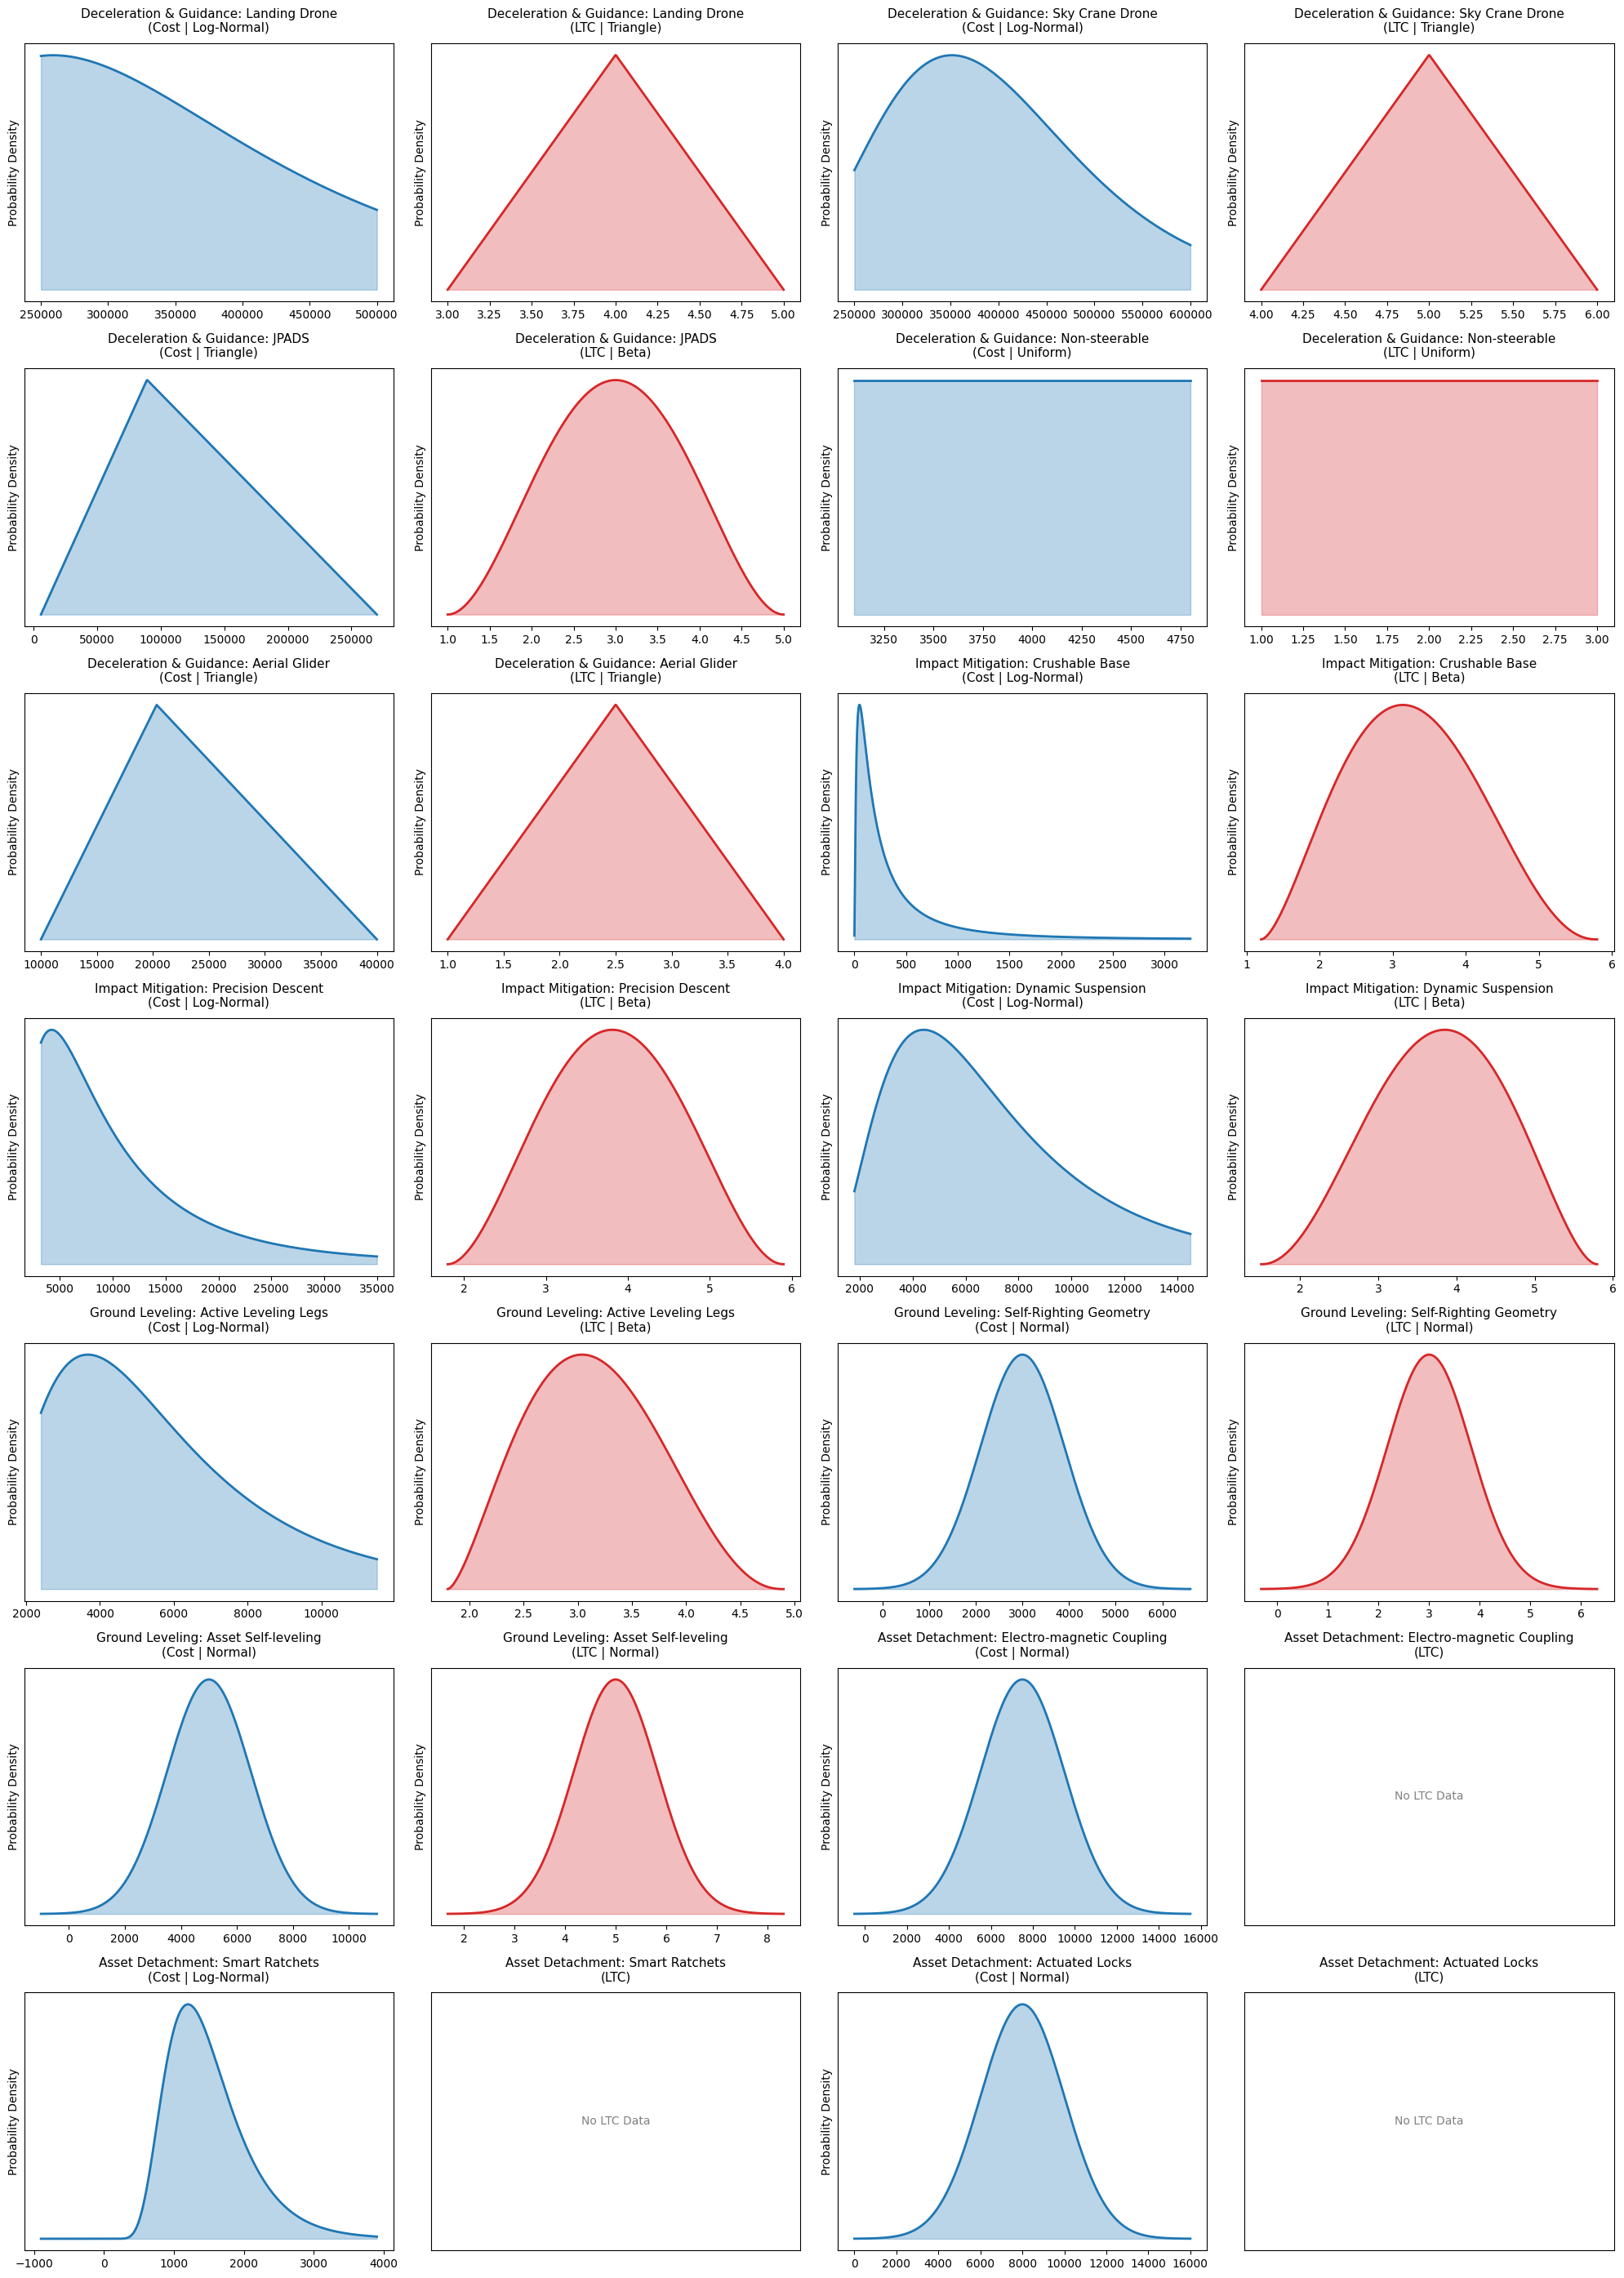

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import math

# Get all unique Decision and Option combinations from the processed dataframe
unique_options = df_processed[['Architectural Decision', 'Option Name']].drop_duplicates()
num_options = len(unique_options)

print(f"--- Plotting Analytical PDFs for all {num_options} Decision Options ---")

# Setup a dynamic grid: 4 columns means 2 Options per row (Cost and LTC for each)
cols = 4
num_plots = num_options * 2  # 2 metrics (Cost, LTC) per option
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
# Ensure axes is flattenable even if there's only 1 row
axes = axes.flatten() if num_plots > 1 else np.array([axes])

plot_idx = 0

# Iterate through every unique option available in the tradespace
for _, opt_row in unique_options.iterrows():
    decision = opt_row['Architectural Decision']
    option_name = opt_row['Option Name']

    # Filter for this specific option
    components = df_processed[
        (df_processed['Architectural Decision'] == decision) &
        (df_processed['Option Name'] == option_name)
    ]

    # Plot Cost first, then LTC
    for metric in ['Cost', 'LTC']:
        ax = axes[plot_idx]
        color = 'tab:blue' if metric == 'Cost' else 'tab:red'

        comp_row = components[components['Metric'] == metric]

        # Handle cases where a metric might be missing for an option
        if comp_row.empty:
            ax.text(0.5, 0.5, f"No {metric} Data", ha='center', va='center', fontsize=10, color='gray')
            ax.set_title(f"{decision}: {option_name}\n({metric})", fontsize=11, pad=10)
            ax.set_xticks([])
            ax.set_yticks([])
            plot_idx += 1
            continue

        comp_row = comp_row.iloc[0]
        pdf_type = comp_row.get('PDF Type', 'Point Estimate')

        # Extract parameters safely
        mean = comp_row.get('Mean', np.nan)
        sd = comp_row.get('SD', np.nan)
        left = comp_row.get('Min', np.nan)
        right = comp_row.get('Max', np.nan)
        alpha_val = comp_row.get('Alpha', np.nan)
        beta_val = comp_row.get('Beta', np.nan)
        shift_val = comp_row.get('Shift', 0) if not pd.isna(comp_row.get('Shift', np.nan)) else 0

        try:
            # --- 1. Determine X-axis plotting range ---
            plot_min = left if not pd.isna(left) else (mean - 4 * sd if not pd.isna(mean) and not pd.isna(sd) and sd > 0 else (mean * 0.8 if mean else 0))
            plot_max = right if not pd.isna(right) else (mean + 4 * sd if not pd.isna(mean) and not pd.isna(sd) and sd > 0 else (mean * 1.2 if mean else 1))

            # Ensure a valid range exists for plotting
            if plot_min >= plot_max:
                plot_min, plot_max = plot_min - 1, plot_max + 1

            x = np.linspace(plot_min, plot_max, 500)
            y = None

            # --- 2. Calculate theoretical PDF values based on type ---
            if pd.isna(mean) and pd.isna(left): # Bad data fallback
                 raise ValueError("Missing Mean or Min")

            elif pdf_type == 'Normal':
                y = stats.norm.pdf(x, loc=mean, scale=sd)

            elif pdf_type == 'Log-Normal':
                if mean > 0 and sd > 0:
                    var = sd**2
                    sigma2 = np.log(1 + (var / mean**2))
                    mu = np.log(mean) - sigma2 / 2
                    sigma = np.sqrt(sigma2)
                    y = stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))

            elif pdf_type == 'Triangle':
                if not pd.isna(left) and not pd.isna(right) and right > left:
                    c = (mean - left) / (right - left)
                    y = stats.triang.pdf(x, c=c, loc=left, scale=right - left)

            elif pdf_type == 'Uniform':
                if not pd.isna(left) and not pd.isna(right) and right > left:
                    y = stats.uniform.pdf(x, loc=left, scale=right - left)

            elif pdf_type == 'Beta':
                if not pd.isna(left) and not pd.isna(right) and right > left:
                    alpha = 1 + 4 * (mean - left) / (right - left)
                    beta_param = 1 + 4 * (right - mean) / (right - left)
                    y = stats.beta.pdf(x, a=alpha, b=beta_param, loc=left, scale=right - left)

            elif pdf_type == 'Gamma':
                if not pd.isna(alpha_val) and not pd.isna(beta_val):
                    y = stats.gamma.pdf(x, a=alpha_val, scale=beta_val, loc=shift_val)
                elif not pd.isna(mean) and not pd.isna(sd) and sd > 0:
                    adj_mean = mean - shift_val
                    if adj_mean > 0:
                        shape_k = (adj_mean / sd) ** 2
                        scale_theta = (sd ** 2) / adj_mean
                        y = stats.gamma.pdf(x, a=shape_k, scale=scale_theta, loc=shift_val)

            elif pdf_type == 'Exponential':
                scale = mean - shift_val
                if scale > 0:
                    if not pd.isna(right):
                        b_trunc = (right - shift_val) / scale
                        if b_trunc > 0:
                            y = stats.truncexpon.pdf(x, b=b_trunc, loc=shift_val, scale=scale)
                    else:
                        y = stats.expon.pdf(x, loc=shift_val, scale=scale)

            # --- 3. Plotting ---
            if y is not None:
                ax.plot(x, y, color=color, linewidth=2)
                ax.fill_between(x, y, color=color, alpha=0.3)
            else:
                # Fallback for point estimates or deterministic entries
                ax.axvline(mean, color=color, linewidth=3)

            ax.set_title(f"{decision}: {option_name}\n({metric} | {pdf_type})", fontsize=11, pad=10)
            ax.set_ylabel('Probability Density')
            ax.set_yticks([])

        except Exception as e:
            ax.text(0.5, 0.5, f"Data Error:\n{str(e)}", ha='center', va='center',
                    wrap=True, fontsize=9, color='red')
            ax.set_title(f"{decision}: {option_name}\n({metric} | {pdf_type})", fontsize=11, pad=10)
            ax.set_xticks([])
            ax.set_yticks([])

        plot_idx += 1

# Clean up any remaining empty subplots in the grid
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Deftermine Possible Architectures:
Generate all valid architectural combinations, calculate their performance, and identify the pareto frontier.


In [4]:
import numpy as np
import pandas as pd
from typing import Sequence, Optional

### Common functions for determining Pareto Front ###

def pareto_mask(points: np.ndarray) -> np.ndarray:
    n = points.shape[0]
    mask = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            # j dominates i if j is better or equal in ALL dims,
            # AND strictly better in AT LEAST one dim.
            if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                mask[i] = False
                break  # i is dominated, stop checking and move on

    return mask


def pareto_frontier(
    df: pd.DataFrame,
    cols: Sequence[str],
    maximize: Optional[Sequence[bool]] = None
) -> pd.DataFrame:
    if maximize is None:
        maximize = [True] * len(cols)

    if len(maximize) != len(cols):
        raise ValueError("The length of 'maximize' flags must match the length of 'cols'.")

    # CRITICAL FIX: Added .copy() to prevent modifying the original dataframe memory
    pts = df[list(cols)].to_numpy(dtype=float).copy()

    # Convert to lower-is-better
    for k, m in enumerate(maximize):
        if m:  # if maximize, negate column
            pts[:, k] = -pts[:, k]

    # Calculate mask and return filtered dataframe
    mask = pareto_mask(pts)
    return df[mask].copy()


In [5]:
import numpy as np
import pandas as pd

def calculate_expected_value(row):
    """
    Calculates the true mathematical expected value (mean) of a distribution.
    Assumes row['Mean'] represents the Mode for Triangular/Beta, or the untruncated
    scale for Exponential.
    """
    pdf_type = str(row.get('PDF Type', '')).strip()
    input_mean = row.get('Mean', np.nan)
    left = row.get('Min', np.nan)
    right = row.get('Max', np.nan)
    shift = row.get('Shift', 0) if not pd.isna(row.get('Shift')) else 0
    alpha_val = row.get('Alpha', np.nan)
    beta_val = row.get('Beta', np.nan)

    # Fallback if no input mean is provided but bounds exist
    if pd.isna(input_mean):
        if not pd.isna(left) and not pd.isna(right):
            input_mean = (left + right) / 2.0
        else:
            return 0  # Ultimate fallback

    if pdf_type in ['Triangular', 'Triangle']:
        # True Mean = (Min + Mode + Max) / 3
        if not pd.isna(left) and not pd.isna(right):
            return (left + input_mean + right) / 3.0

    elif pdf_type == 'Uniform':
        # True Mean = (Min + Max) / 2
        if not pd.isna(left) and not pd.isna(right):
            return (left + right) / 2.0

    elif pdf_type == 'Beta':
        # Using standard PERT expected value: (Min + 4*Mode + Max) / 6
        if not pd.isna(left) and not pd.isna(right):
            return (left + 4 * input_mean + right) / 6.0

    elif pdf_type == 'Gamma':
        # If user explicitly provided Shape (Alpha) and Scale (Beta)
        if not pd.isna(alpha_val) and not pd.isna(beta_val):
            return (alpha_val * beta_val) + shift

    elif pdf_type == 'Exponential':
        scale = input_mean - shift
        if not pd.isna(right) and scale > 0:
            # Expected value of a TRUNCATED exponential distribution
            b_trunc = right - shift
            if b_trunc > 0:
                # Formula: Scale - B / (exp(B/Scale) - 1)
                true_mean_shifted = scale - (b_trunc / (np.exp(b_trunc / scale) - 1))
                return true_mean_shifted + shift

    # For Normal, Log-Normal, standard Exponential, Point Estimates, or unrecognized types
    return input_mean


# Add calculated Expected Value to df_processed
df_processed['Expected Value'] = df_processed.apply(calculate_expected_value, axis=1)

In [6]:
import itertools
import numpy as np
import pandas as pd
from typing import Sequence, Optional

# 1. Extract Architectural Decision categories and options
decisions = df_processed['Architectural Decision'].unique()
decision_options = {}

for decision in decisions:
    # Get unique options for this decision
    options = df_processed[df_processed['Architectural Decision'] == decision]['Option Name'].unique()
    decision_options[decision] = options

# 2. Generate all possible combinations
keys = decision_options.keys()
values = decision_options.values()
combinations = list(itertools.product(*values))

print(f"Total number of unique architectures: {len(combinations)}")

# 3. Calculate Deterministic Performance & Create DataFrame
arch_data = []

# Pre-filter df_processed for speed
cost_df = df_processed[df_processed['Metric'] == 'Cost'].set_index(['Architectural Decision', 'Option Name'])
ltc_df = df_processed[df_processed['Metric'] == 'LTC'].set_index(['Architectural Decision', 'Option Name'])

for i, combo in enumerate(combinations):
    total_cost = 0
    total_ltc = 0
    is_valid = True

    current_arch_dict = {'Arch_ID': i}

    for decision, option in zip(keys, combo):
        current_arch_dict[decision] = option

        # ### Cost & LTC as a product of entered mean value, does not take PDF type into account ###
        # # Add Cost
        # try:
        #     val = cost_df.loc[(decision, option), 'Mean']
        #     if isinstance(val, pd.Series): val = val.iloc[0]

        #     # Strict check: If Mean is missing, fail loudly
        #     if pd.isna(val):
        #         raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option}' under decision '{decision}' (Metric: Cost).")
        #     else:
        #         total_cost += val
        # except KeyError:
        #     pass # Perfectly fine, this option just doesn't affect Cost

        # # Add LTC
        # try:
        #     val = ltc_df.loc[(decision, option), 'Mean']
        #     if isinstance(val, pd.Series): val = val.iloc[0]

        #     # Strict check: If Mean is missing, fail loudly
        #     if pd.isna(val):
        #         raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option}' under decision '{decision}' (Metric: LTC).")
        #     else:
        #         total_ltc += val
        # except KeyError:
        #     pass # Perfectly fine, this option just doesn't affect LTC (e.g., Asset Detachment)


        ### Aligned to PDFs for each option - uses calculated Expected Value (instead of simple mean)###
        # Add Cost
        try:
            val = cost_df.loc[(decision, option), 'Expected Value']
            if isinstance(val, pd.Series): val = val.iloc[0]

            # Strict check: If Expected Value is missing, fail loudly
            if pd.isna(val):
                raise ValueError(f"Data Error: Missing 'Expected Value' for option '{option}' under decision '{decision}' (Metric: Cost).")
            else:
                total_cost += val
        except KeyError:
            pass # Perfectly fine, this option just doesn't affect Cost

        # Add LTC
        try:
            val = ltc_df.loc[(decision, option), 'Expected Value']
            if isinstance(val, pd.Series): val = val.iloc[0]

            # Strict check: If Expected Value is missing, fail loudly
            if pd.isna(val):
                raise ValueError(f"Data Error: Missing 'Expected Value' for option '{option}' under decision '{decision}' (Metric: LTC).")
            else:
                total_ltc += val
        except KeyError:
            pass # Perfectly fine, this option just doesn't affect LTC (e.g., Asset Detachment)

    current_arch_dict['Total_Cost'] = total_cost if is_valid else np.nan
    current_arch_dict['Total_LTC'] = total_ltc if is_valid else np.nan
    arch_data.append(current_arch_dict)

df_architectures = pd.DataFrame(arch_data)


# # --- Normalize LTC to 1-6 Range ---
# valid_mask = df_architectures['Total_LTC'].notna()

# if valid_mask.any():
#     min_ltc = df_architectures.loc[valid_mask, 'Total_LTC'].min()
#     max_ltc = df_architectures.loc[valid_mask, 'Total_LTC'].max()

#     # Normalize Total_LTC to a 0-6 range
#     if max_ltc > min_ltc:
#         df_architectures.loc[valid_mask, 'Total_LTC'] = (
#             1.0 + (df_architectures.loc[valid_mask, 'Total_LTC'] - min_ltc) / (max_ltc - min_ltc) * 5.0
#         )


# 4. Identify the Pareto Frontier
df_valid = df_architectures.dropna(subset=['Total_LTC', 'Total_Cost']).copy()

# Find the Pareto frontier on the valid data
front = pareto_frontier(df_valid, ['Total_LTC','Total_Cost'], maximize=[True, False])

# Update df_architectures
pareto_arch_ids = set(front['Arch_ID'].values)
df_architectures['is_pareto'] = df_architectures['Arch_ID'].isin(pareto_arch_ids)

print(f"Number of valid architectures evaluated: {len(df_valid)}")
print(f"Number of architectures on the Pareto frontier: {len(front)}")
display(front)

Total number of unique architectures: 135
Number of valid architectures evaluated: 135
Number of architectures on the Pareto frontier: 14


,Arch_ID,Deceleration & Guidance,Impact Mitigation,Ground Leveling,Asset Detachment,Total_Cost,Total_LTC
7,7,Landing Drone,Crushable Base,Asset Self-leveling,Smart Ratchets,356974.540000,12.260000
16,16,Landing Drone,Precision Descent,Asset Self-leveling,Smart Ratchets,367786.000000,12.823333
25,25,Landing Drone,Dynamic Suspension,Asset Self-leveling,Smart Ratchets,363914.000000,12.783333
34,34,Sky Crane Drone,Crushable Base,Asset Self-leveling,Smart Ratchets,406974.540000,13.260000
43,43,Sky Crane Drone,Precision Descent,Asset Self-leveling,Smart Ratchets,417786.000000,13.823333
52,52,Sky Crane Drone,Dynamic Suspension,Asset Self-leveling,Smart Ratchets,413914.000000,13.783333
70,70,JPADS,Precision Descent,Asset Self-leveling,Smart Ratchets,139452.666667,11.823333
79,79,JPADS,Dynamic Suspension,Asset Self-leveling,Smart Ratchets,135580.666667,11.783333
85,85,Non-steerable,Crushable Base,Self-Righting Geometry,Smart Ratchets,8924.540000,8.260000
88,88,Non-steerable,Crushable Base,Asset Self-leveling,Smart Ratchets,10924.540000,10.260000


### Visualize Architectures & Pareto Frontier

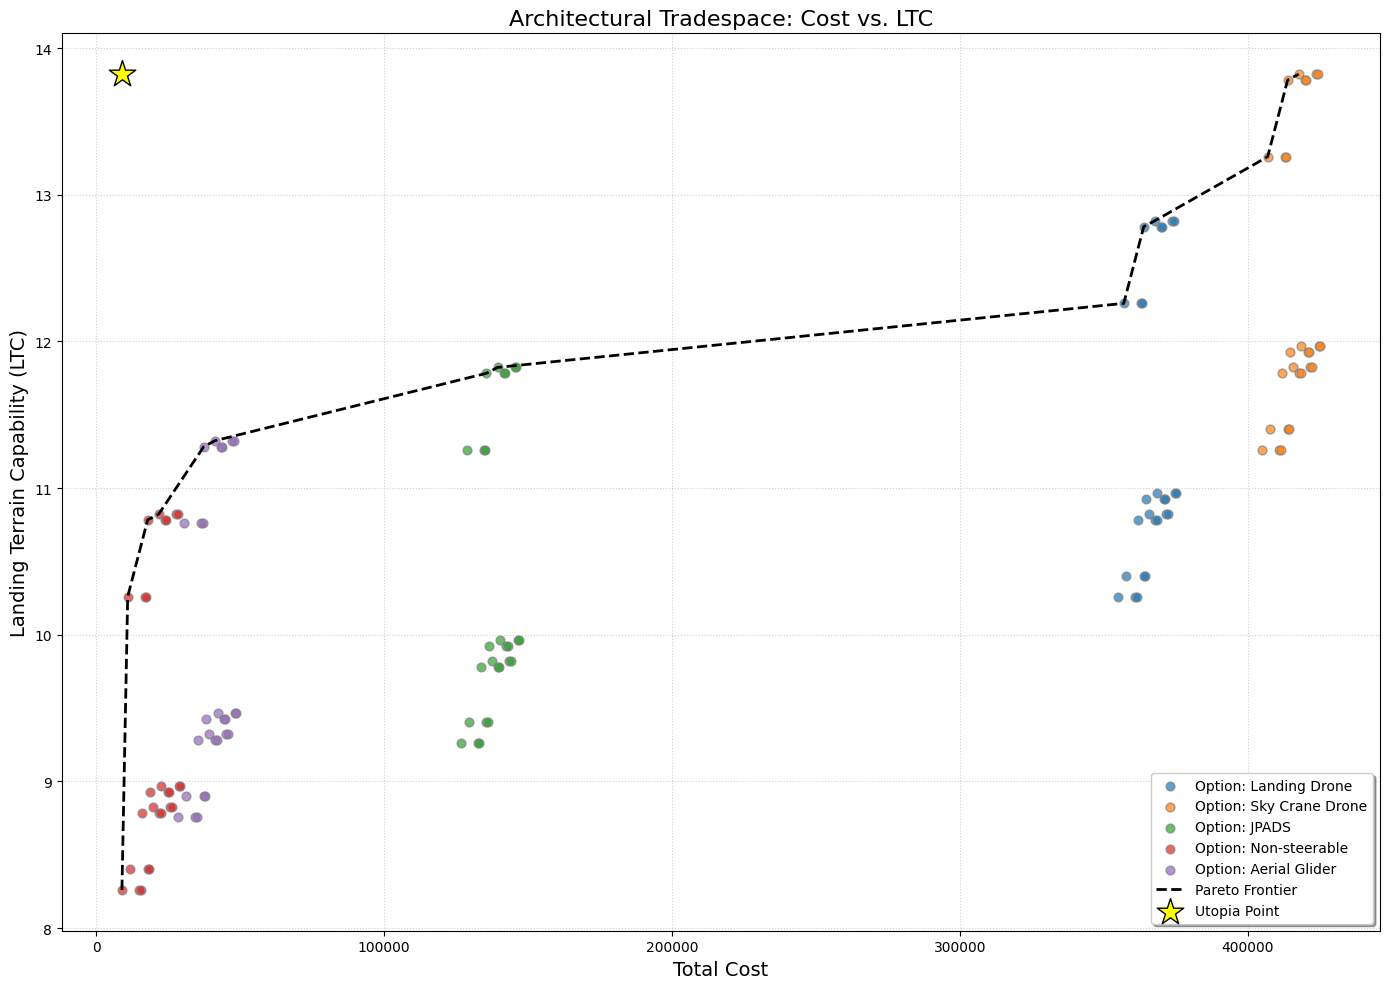

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(14, 10))

# Define the specific options and assign distinct colors using standard matplotlib tab colors
option_colors = {
    'Landing Drone': 'tab:blue',
    'Sky Crane Drone': 'tab:orange',
    'JPADS': 'tab:green',
    'Non-steerable': 'tab:red',
    'Aerial Glider': 'tab:purple'
}

# 1. Plot Architectures colored by Option Name
# We loop through the dictionary to plot each group and assign it a label for the legend
for option, color in option_colors.items():
    # FIXED: Changed 'Option' to lowercase 'option' to match the loop variable
    subset = df_architectures[df_architectures['Deceleration & Guidance'] == option]

    # Plot this specific subset
    plt.scatter(subset['Total_Cost'], subset['Total_LTC'],
                c=color, label=f'Option: {option}', alpha=0.7, s=40, edgecolors='grey')

# (Optional) Plot any remaining architectures that don't match the 5 listed above as grey
# FIXED: Replaced undefined variable 'decision_col' with the actual column name string
other_archs = df_architectures[~df_architectures['Deceleration & Guidance'].isin(option_colors.keys())]
if not other_archs.empty:
    plt.scatter(other_archs['Total_Cost'], other_archs['Total_LTC'],
                c='lightgrey', label='Other Architectures', alpha=0.5, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Pareto Frontier')

# 3. DYNAMIC UTOPIA POINT (Min Cost and Max LTC)
utopia_cost = df_architectures['Total_Cost'].min()
utopia_ltc = df_architectures['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point')

plt.title('Architectural Tradespace: Cost vs. LTC', fontsize=16)
plt.xlabel('Total Cost', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# Place legend outside the plot or adjust location so it doesn't cover your points
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Select Architectures to Evaluate

In [37]:
import numpy as np

# 5. Select 8 Architectures
# Strategy:
# - First 6: 1 from each 'Deceleration & Guidance' category (Pareto preferred).
#   If there are fewer than 6 categories, fill the rest with other Pareto points.
# - Last 2: Sampled from the absolute WORST ("Pretty Bad") non-Pareto architectures.

selected_indices = []

# Assuming the column name in df_architectures matches your spreadsheet decision name
dec_guidance_col = 'Deceleration & Guidance'

# Get all unique options for this category (e.g., Landing Drone, JPADS, etc.)
categories = df_architectures[dec_guidance_col].unique()

# --- STEP 1: Select up to 6 architectures (1 per category, preferring Pareto) ---
for category in categories:
    if len(selected_indices) >= 6:
        break  # Stop picking by category if we already reached 6

    # Filter the dataframe for architectures that use this specific category
    subset = df_architectures[df_architectures[dec_guidance_col] == category]

    # Filter that subset further to see if any are on the Pareto frontier
    pareto_subset = subset[subset['is_pareto']]

    if not pareto_subset.empty:
        # Prefer: Randomly select one from the Pareto frontier
        chosen_idx = np.random.choice(pareto_subset.index)
    elif not subset.empty:
        # Fallback: Randomly select one from the non-Pareto subset
        chosen_idx = np.random.choice(subset.index)
    else:
        continue

    selected_indices.append(chosen_idx)

# If we picked fewer than 6 (e.g., only 5 categories exist), fill up to 6 with remaining Pareto points
num_needed_first_group = 6 - len(selected_indices)
if num_needed_first_group > 0:
    remaining_pareto = df_architectures[
        (df_architectures['is_pareto']) &
        (~df_architectures.index.isin(selected_indices))
    ].index.tolist()

    if len(remaining_pareto) > 0:
        fill_indices = np.random.choice(
            remaining_pareto,
            size=min(num_needed_first_group, len(remaining_pareto)),
            replace=False
        ).tolist()
        selected_indices.extend(fill_indices)

# --- STEP 2: Select 2 "Pretty Bad" architectures ---
# We want exactly 8 total, so we need (8 - current length) more, which should be 2.
num_needed_second_group = 8 - len(selected_indices)

if num_needed_second_group > 0:
    # Get all NON-Pareto points that we haven't already selected
    df_non_pareto = df_architectures[
        (~df_architectures['is_pareto']) &
        (~df_architectures.index.isin(selected_indices))
    ].copy()

    if not df_non_pareto.empty:
        # Calculate a "Badness Score" based on rank
        # High Cost Rank (Expensive) - High LTC Rank (Highly Capable)
        # Result: Huge positive numbers mean Extremely Expensive AND Terrible LTC
        df_non_pareto['Badness_Score'] = (
            df_non_pareto['Total_Cost'].rank(ascending=True) -
            df_non_pareto['Total_LTC'].rank(ascending=True)
        )

        # Take the top 10 absolute worst architectures to form a "bad pool"
        worst_pool = df_non_pareto.nlargest(10, 'Badness_Score').index.tolist()

        # Randomly select the remaining needed amount from this terrible pool
        fill_indices = np.random.choice(
            worst_pool,
            size=min(num_needed_second_group, len(worst_pool)),
            replace=False
        ).tolist()
        selected_indices.extend(fill_indices)

# --- STEP 3: Create the final DataFrame ---
selected_architectures = df_architectures.loc[selected_indices].copy()

print(f"Selected {len(selected_architectures)} architectures.")
display(selected_architectures)

Selected 8 architectures.


,Arch_ID,Deceleration & Guidance,Impact Mitigation,Ground Leveling,Asset Detachment,Total_Cost,Total_LTC,is_pareto
16,16,Landing Drone,Precision Descent,Asset Self-leveling,Smart Ratchets,367786.000000,12.823333,True
34,34,Sky Crane Drone,Crushable Base,Asset Self-leveling,Smart Ratchets,406974.540000,13.260000,True
79,79,JPADS,Dynamic Suspension,Asset Self-leveling,Smart Ratchets,135580.666667,11.783333,True
85,85,Non-steerable,Crushable Base,Self-Righting Geometry,Smart Ratchets,8924.540000,8.260000,True
124,124,Aerial Glider,Precision Descent,Asset Self-leveling,Smart Ratchets,41230.333333,11.323333,True
7,7,Landing Drone,Crushable Base,Asset Self-leveling,Smart Ratchets,356974.540000,12.260000,True
57,57,JPADS,Crushable Base,Self-Righting Geometry,Electro-magnetic Coupling,132641.206667,9.260000,False
5,5,Landing Drone,Crushable Base,Self-Righting Geometry,Actuated Locks,361474.540000,10.260000,False


## Calculate PDFs & Run Monte Carlo Simulation


In [38]:
import numpy as np
import pandas as pd

# Number of Monte Carlo samples
N_SAMPLES = 2000
np.random.seed(42)

# Dictionary to store simulation results for each selected architecture
simulation_results = {}

# Perform Simulation
for idx, row in selected_architectures.iterrows():
    arch_id = row['Arch_ID']

    # Initialize arrays for summing samples
    total_cost_samples = np.zeros(N_SAMPLES)
    total_ltc_samples = np.zeros(N_SAMPLES)

    # Iterate through each decision to get the specific option
    for decision in decisions:
        option_name = row[decision]

        components = df_processed[
            (df_processed['Architectural Decision'] == decision) &
            (df_processed['Option Name'] == option_name)
        ]

        for _, comp_row in components.iterrows():
            metric = comp_row['Metric']
            pdf_type = comp_row['PDF Type']

            # Read all required statistical columns
            mean = comp_row['Mean']
            sd = comp_row['SD']
            left = comp_row['Min']
            right = comp_row['Max']
            alpha = comp_row['Alpha']
            beta = comp_row['Beta']
            shift = comp_row.get('Shift', np.nan) # Safely get Shift input

            # --- 1. NORMAL & LOG-NORMAL VALIDATION ---
            if pdf_type in ['Normal', 'Log-Normal']:
                if pd.isna(mean):
                    raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")
                if pd.isna(sd):
                    raise ValueError(f"Spreadsheet Error: Missing 'SD' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")

                if pdf_type == 'Normal':
                    samples = np.random.normal(mean, sd, N_SAMPLES)
                else: # Log-Normal
                    if mean <= 0:
                        samples = np.zeros(N_SAMPLES)
                    else:
                        var = sd**2
                        sigma2 = np.log(1 + (var / mean**2))
                        mu = np.log(mean) - sigma2 / 2
                        sigma = np.sqrt(sigma2)
                        samples = np.random.lognormal(mu, sigma, N_SAMPLES)

            # --- 2. Triangle VALIDATION ---
            elif pdf_type == 'Triangle':
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(mean): missing_cols.append('Mean (used as Mode)')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type 'Triangular'. Please populate these columns.")

                # Uses Mean as the mode (peak) of the triangle
                samples = np.random.triangular(left, mean, right, N_SAMPLES)

            # --- 3. UNIFORM VALIDATION ---
            elif pdf_type == 'Uniform':
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type 'Uniform'. Please populate these columns.")

                samples = np.random.uniform(left, right, N_SAMPLES)

            # --- 4. BETA VALIDATION (Handles Symmetrical, Left-Skewed, Right-Skewed) ---
            elif pdf_type == 'Beta':
                missing_cols = []
                if pd.isna(left): missing_cols.append('Min')
                if pd.isna(mean): missing_cols.append('Mean (used as Mode)')
                if pd.isna(right): missing_cols.append('Max')

                if missing_cols:
                    raise ValueError(f"Spreadsheet Error: Missing {missing_cols} for option '{option_name}' ({metric}) with PDF Type 'Beta'. Please populate these columns.")

                # Logical check to ensure the peak (mean/mode) is actually within the boundaries
                if not (left <= mean <= right):
                    raise ValueError(f"Spreadsheet Error: '{option_name}' ({metric}) has a Mean ({mean}) outside the Min ({left}) and Max ({right}) range.")

                if left >= right:
                    raise ValueError(f"Spreadsheet Error: '{option_name}' ({metric}) has a Min ({left}) that is greater than or equal to Max ({right}).")

                # The PERT scaling formula automatically creates the correct shape:
                # - Symmetrical: if Mean is exactly in the middle of Min and Max
                # - Right-skewed (Tail on right): if Mean is closer to Min
                # - Left-skewed (Tail on left): if Mean is closer to Max
                alpha = 1 + 4 * (mean - left) / (right - left)
                beta = 1 + 4 * (right - mean) / (right - left)

                samples = left + (right - left) * np.random.beta(alpha, beta, N_SAMPLES)

            # --- 5. GAMMA VALIDATION (Handles Shift, Alpha/Beta, or Mean/SD inputs) ---
            elif pdf_type == 'Gamma':
                # Safely get Alpha and Beta if they exist in the dataframe
                alpha_val = comp_row.get('Alpha', np.nan)
                beta_val = comp_row.get('Beta', np.nan)

                # Default shift to 0 if not provided, allowing standard unshifted Gamma
                shift_val = 0 if pd.isna(shift) else shift

                # Route 1: User provided Alpha (Shape) and Beta (Scale) directly
                if not pd.isna(alpha_val) and not pd.isna(beta_val):
                    if alpha_val <= 0 or beta_val <= 0:
                        raise ValueError(f"Spreadsheet Error: 'Alpha' and 'Beta' must be > 0 for option '{option_name}' ({metric}).")
                    shape_k = alpha_val
                    scale_theta = beta_val # Assuming Beta input represents the Scale parameter

                # Route 2: Calculate from Mean and SD
                elif not pd.isna(mean) and not pd.isna(sd):
                    if mean <= shift_val:
                        raise ValueError(f"Spreadsheet Error: 'Mean' ({mean}) must be > 'Shift' ({shift_val}) for option '{option_name}' ({metric}).")
                    if sd <= 0:
                        raise ValueError(f"Spreadsheet Error: 'SD' must be > 0 for option '{option_name}' ({metric}).")

                    # Calculate adjusted mean for the shift
                    adjusted_mean = mean - shift_val

                    # Convert Adjusted Mean and SD to Gamma Shape (k) and Scale (theta)
                    shape_k = (adjusted_mean / sd) ** 2
                    scale_theta = (sd ** 2) / adjusted_mean

                # Route 3: Missing required data
                else:
                    raise ValueError(f"Spreadsheet Error: Missing parameters for option '{option_name}' ({metric}) with PDF Type 'Gamma'. Please provide either (Alpha & Beta) OR (Mean & SD).")

                # Generate samples and shift them
                samples = np.random.gamma(shape_k, scale_theta, N_SAMPLES) + shift_val

            # --- 6. EXPONENTIAL VALIDATION (Shifted & Truncated) ---
            elif pdf_type == 'Exponential':
                if pd.isna(shift):
                    raise ValueError(f"Spreadsheet Error: Missing 'Shift' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")
                if pd.isna(mean):
                    raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")

                # Mean must be strictly greater than Shift for the shift to work
                if mean <= shift:
                    raise ValueError(f"Spreadsheet Error: 'Mean' must be > 'Shift' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")

                # Calculate the scale (1/lambda) for the underlying exponential curve
                scale = mean - shift

                # Check if an upper truncation (Max) is provided
                if not pd.isna(right):
                    if right <= shift:
                        raise ValueError(f"Spreadsheet Error: 'Max' must be > 'Shift' for option '{option_name}' ({metric}) with PDF Type '{pdf_type}'.")

                    # Calculate effective max range and apply Inverse Transform Sampling
                    eff_max = right - shift
                    uniform_samples = np.random.uniform(0, 1, N_SAMPLES)
                    samples = -scale * np.log(1 - uniform_samples * (1 - np.exp(-eff_max / scale))) + shift
                else:
                    # Standard shifted exponential (no max limit)
                    samples = np.random.exponential(scale, N_SAMPLES) + shift

            # --- 7. FALLBACK / UNKNOWN PDF TYPE ---
            else:
                if pd.isna(mean):
                    raise ValueError(f"Spreadsheet Error: Missing 'Mean' for option '{option_name}' ({metric}). Unknown PDF Type: '{pdf_type}'.")
                samples = np.full(N_SAMPLES, mean)

            # Sum the results
            if metric == 'Cost':
                total_cost_samples += samples
            elif metric == 'LTC':
                total_ltc_samples += samples

    simulation_results[arch_id] = {
        'Cost_Samples': total_cost_samples,
        'LTC_Samples': total_ltc_samples,
        'is_pareto': row.get('is_pareto', False)
    }

print(f"Simulation completed for {len(simulation_results)} architectures with {N_SAMPLES} samples each.")

Simulation completed for 8 architectures with 2000 samples each.


## Determine Uncertainty Bands

Find "best' architectures on the new pareto frontier AND 'worst' architectures on the anti-pareto frontier.

In [39]:
##Generate New Pareto Frontier##

# 1. Create df_simulation_data. Transpose the data in the simulation_data array
rows = []
for aid, entry in simulation_results.items():
    n = np.asarray(entry['Cost_Samples']).size
    rows.append(pd.DataFrame({
        'Arch_ID': aid,
        'Sample_ID': [f"{aid}_{i}" for i in range(n)],
        'Sample_Order': np.arange(n),
        'Total_Cost': entry['Cost_Samples'],
        'Total_LTC': entry['LTC_Samples'],
    }))
df_simulation_data = pd.concat(rows, ignore_index=True)

# # 1.5. Normalize Total_LTC in df_simulation_data to a 1-6 range
# min_ltc = df_simulation_data['Total_LTC'].min()
# max_ltc = df_simulation_data['Total_LTC'].max()

# # Check to avoid division by zero if all values are the same
# if max_ltc > min_ltc:
#     # FIX: Apply normalization directly to the simulation data
#     df_simulation_data['Total_LTC'] = (
#         1.0 + (df_simulation_data['Total_LTC'] - min_ltc) / (max_ltc - min_ltc) * 5.0
#     )

#     # FIX: Apply the EXACT SAME transformation to the deterministic architectures
#     # so your baseline points don't float off the graph
#     if 'df_architectures' in locals() and 'Total_LTC' in df_architectures.columns:
#         df_architectures['Total_LTC'] = (
#             1.0 + (df_architectures['Total_LTC'] - min_ltc) / (max_ltc - min_ltc) * 5.0
#         )
# else:
#     df_simulation_data['Total_LTC'] = 1.0
#     if 'df_architectures' in locals() and 'Total_LTC' in df_architectures.columns:
#         df_architectures['Total_LTC'] = 1.0

# print("Total_LTC normalized to 1-6 range.")


# 2. Identify the Pareto and Anti-Pareto Frontiers
# Drop missing/NaN simulation samples to prevent them from breaking the math
df_valid_sim = df_simulation_data.dropna(subset=['Total_LTC', 'Total_Cost']).copy()

# Find the BEST Pareto frontier (Maximize 'Total_LTC', Minimize 'Total_Cost')
front = pareto_frontier(df_valid_sim, ['Total_LTC', 'Total_Cost'], maximize=[True, False])

# Find the WORST Anti-Pareto frontier (Minimize 'Total_LTC', Maximize 'Total_Cost')
# Notice how we just flipped the boolean flags!
anti_front = pareto_frontier(df_valid_sim, ['Total_LTC', 'Total_Cost'], maximize=[False, True])


# 3. Update df_simulation_data with both frontiers
pareto_sample_ids = set(front['Sample_ID'].values)
anti_pareto_sample_ids = set(anti_front['Sample_ID'].values)

# Apply the booleans to the main dataframe
df_simulation_data['is_new_pareto'] = df_simulation_data['Sample_ID'].isin(pareto_sample_ids)
df_simulation_data['anti_pareto_front'] = df_simulation_data['Sample_ID'].isin(anti_pareto_sample_ids)


# Display results
print(f"Total simulated samples: {len(df_simulation_data)}")
print(f"Valid samples evaluated: {len(df_valid_sim)}")
print(f"Samples on the Best (Pareto) frontier: {len(front)}")
print("\nBest Possible Architectures:")
display(front)

# Preview the absolute worst architectures
df_worst = df_simulation_data[df_simulation_data['anti_pareto_front']]
print(f"Samples on the Worst (Anti-Pareto) frontier: {len(anti_front)}")
print("\nWorst Possible Architectures:")
display(df_worst)

Total simulated samples: 16000
Valid samples evaluated: 16000
Samples on the Best (Pareto) frontier: 25

Best Possible Architectures:


,Arch_ID,Sample_ID,Sample_Order,Total_Cost,Total_LTC
746,16,16_746,746,354726.130168,18.002443
2268,34,34_268,268,279899.858523,16.956196
3670,34,34_1670,1670,303764.016552,17.530126
4622,79,79_622,622,20596.878974,13.258114
4945,79,79_945,945,169755.862366,16.116449
5116,79,79_1116,1116,64092.469549,16.091545
5221,79,79_1221,1221,27041.671462,14.212167
6171,85,85_171,171,5089.245954,8.625847
6460,85,85_460,460,5583.009572,10.361264
6831,85,85_831,831,6995.923935,11.371645


Samples on the Worst (Anti-Pareto) frontier: 10

Worst Possible Architectures:


,Arch_ID,Sample_ID,Sample_Order,Total_Cost,Total_LTC,is_new_pareto,anti_pareto_front
209,16,16_209,209,1.790974e+06,12.635476,False,True
1957,16,16_1957,1957,1.308120e+06,11.942143,False,True
12646,57,57_646,646,1.911181e+05,3.663895,False,True
13915,57,57_1915,1915,2.738442e+05,4.694041,False,True
14054,5,5_54,54,1.165999e+06,8.518450,False,True
14084,5,5_84,84,9.470339e+05,7.918816,False,True
14944,5,5_944,944,6.741662e+05,6.371972,False,True
15187,5,5_1187,1187,7.784953e+05,7.178461,False,True
15529,5,5_1529,1529,1.261524e+06,10.379331,False,True
15847,5,5_1847,1847,8.917355e+05,7.357150,False,True


# Graph Monte Carlo Simulation


##Option 1

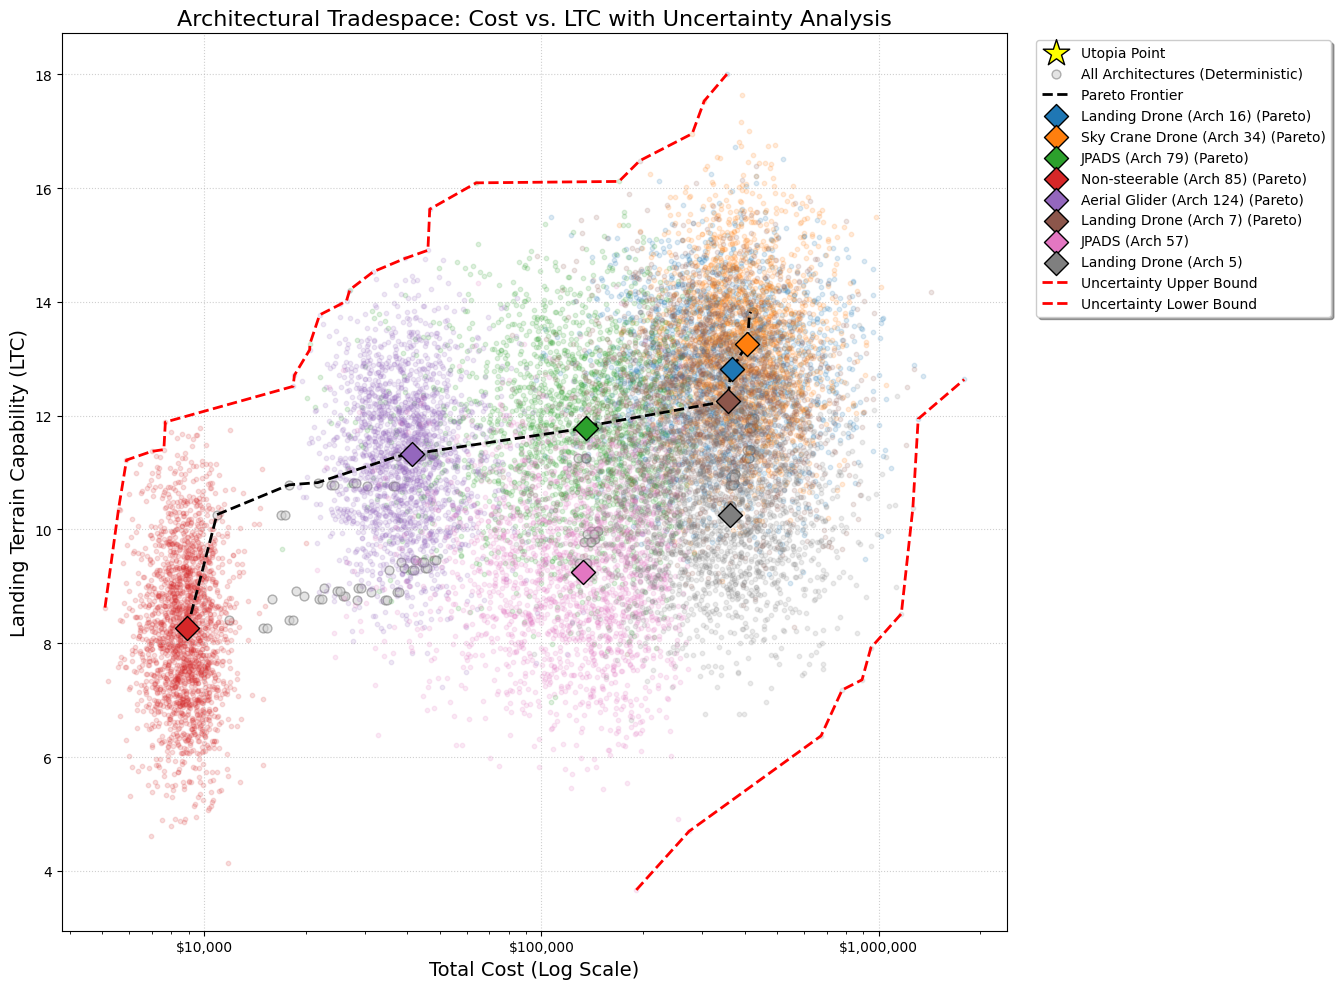

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm

plt.figure(figsize=(14, 10))

# 0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Pareto Frontier')

# 3. Plot Simulation Results (Uncertainty Clouds) from DataFrame
# Get unique architectures that were simulated
simulated_archs = df_simulation_data['Arch_ID'].unique()
colors = plt.get_cmap('tab10')

for i, arch_id in enumerate(simulated_archs):
    color = colors(i)

    # Filter simulation data for this specific architecture
    arch_data = df_simulation_data[df_simulation_data['Arch_ID'] == arch_id]

    # Plot the MC samples (Uncertainty Region)
    plt.scatter(arch_data['Total_Cost'], arch_data['Total_LTC'],
                color=color, alpha=0.15, s=10)

    # Plot the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if det_row.get('is_pareto', False) else ""

    # --- UPDATED LOGIC HERE: Get the Deceleration & Guidance name ---
    dec_guidance_name = det_row.get('Deceleration & Guidance', 'Unknown Category')

    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f"{dec_guidance_name} (Arch {arch_id}) {status_label}")

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Upper Bound')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Lower Bound')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost (Log Scale)', fontsize=14)  # <--- Updated label
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# --- NEW CODE FOR LOG SCALE ---
plt.xscale('log') # Converts the X-axis to logarithmic

# Formats the ticks to display as "$10,000" instead of "10^4"
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)
# ------------------------------

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 2

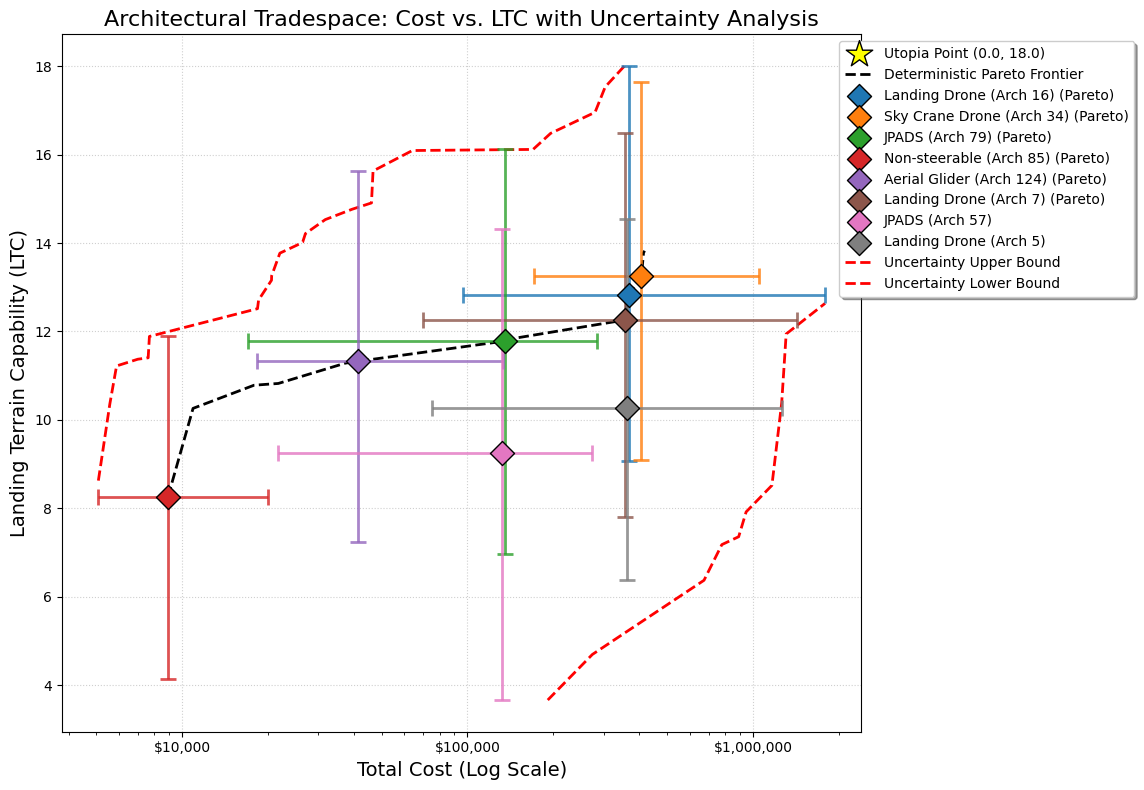

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.figure(figsize=(12, 8))

#0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Uncertainty Crosses (No Scatter Clouds)
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i)

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if res.get('is_pareto', False) else ""

    # Calculate asymmetric distances for the cross lines
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    # Use max(0, value) to ensure we never pass negative error bounds to matplotlib
    left_err = max(0, det_row['Total_Cost'] - min_cost)
    right_err = max(0, max_cost - det_row['Total_Cost'])
    bottom_err = max(0, det_row['Total_LTC'] - min_ltc)
    top_err = max(0, max_ltc - det_row['Total_LTC'])

    # Plot the "Cross" (Error bars with end caps)
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)

    # --- UPDATED LOGIC HERE: Get the Deceleration & Guidance name ---
    dec_guidance_name = det_row.get('Deceleration & Guidance', 'Unknown Category')

    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f"{dec_guidance_name} (Arch {arch_id}) {status_label}")

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Upper Bound')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Lower Bound')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost (Log Scale)', fontsize=14)  # <--- Updated label
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# --- NEW CODE FOR LOG SCALE ---
plt.xscale('log') # Converts the X-axis to logarithmic

# Formats the ticks to display as "$10,000" instead of "10^4"
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)
# ------------------------------

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

###Option 3

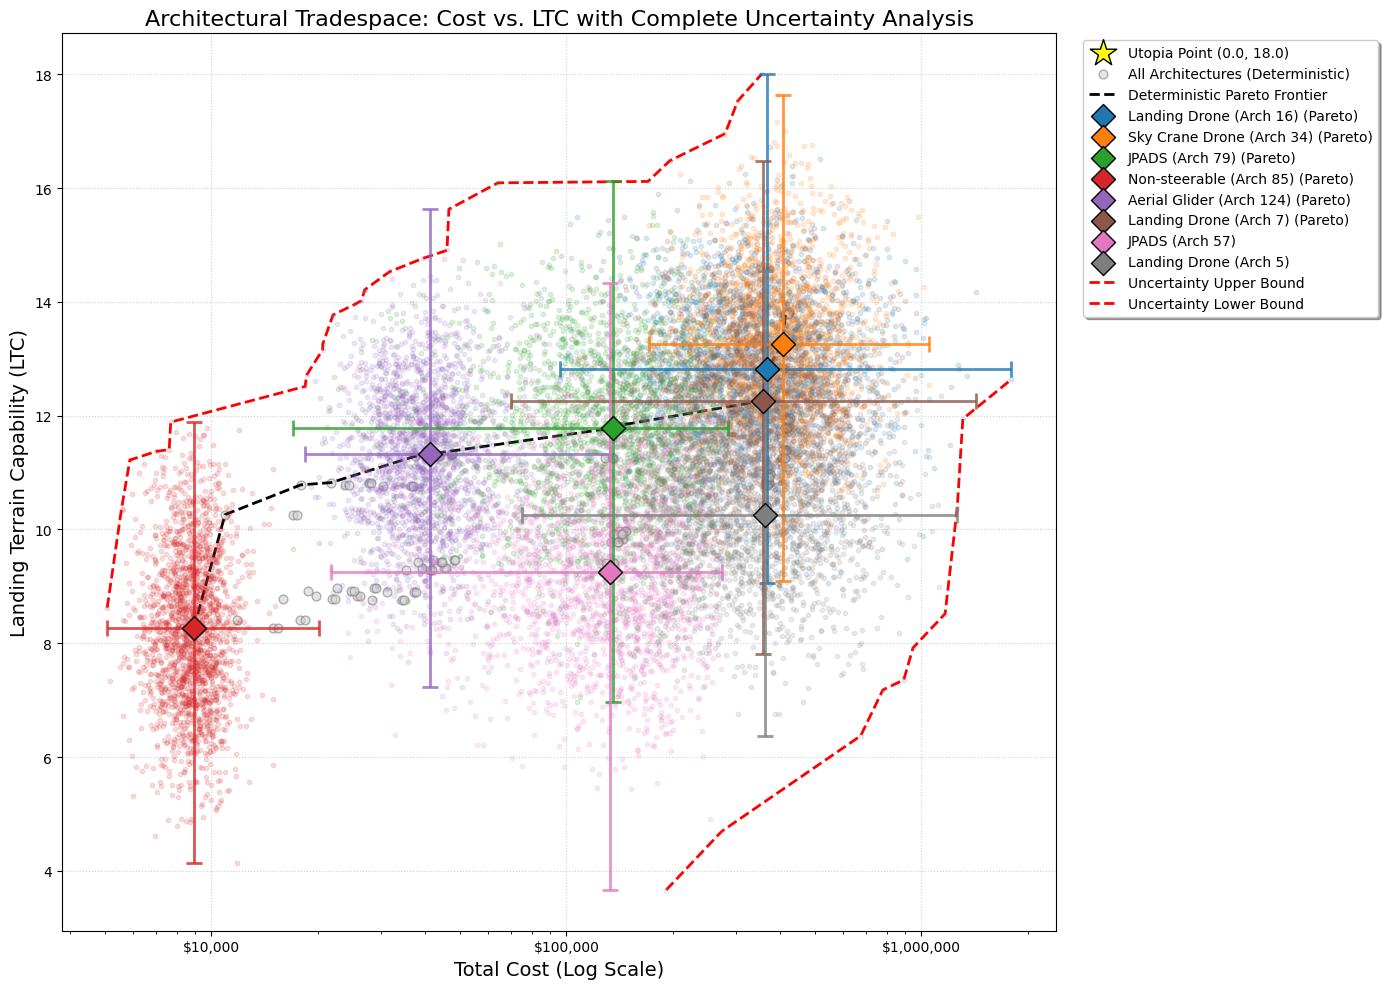

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import numpy as np

plt.figure(figsize=(14, 10))

# 0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point ({utopia_cost:.1f}, {utopia_ltc:.1f})')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Deterministic Pareto Frontier')

# 3. Plot Uncertainty Clouds AND Crosses
colors = plt.get_cmap('tab10')

for i, (arch_id, res) in enumerate(simulation_results.items()):
    color = colors(i % 10) # Modulo 10 prevents index out of bounds error

    # Grab the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if det_row.get('is_pareto', False) else ""

    # --- Plot the Scatter Clouds ---
    # Filter simulation data for this specific architecture
    arch_data = df_simulation_data[df_simulation_data['Arch_ID'] == arch_id]
    plt.scatter(arch_data['Total_Cost'], arch_data['Total_LTC'],
                color=color, alpha=0.15, s=10, zorder=5)

    # --- Plot the Uncertainty Crosses ---
    min_cost, max_cost = np.min(res['Cost_Samples']), np.max(res['Cost_Samples'])
    min_ltc, max_ltc = np.min(res['LTC_Samples']), np.max(res['LTC_Samples'])

    # Use max(0, value) to ensure we never pass negative error bounds to matplotlib
    left_err = max(0, det_row['Total_Cost'] - min_cost)
    right_err = max(0, max_cost - det_row['Total_Cost'])
    bottom_err = max(0, det_row['Total_LTC'] - min_ltc)
    top_err = max(0, max_ltc - det_row['Total_LTC'])

    # Plot the Error bars with end caps
    plt.errorbar(x=det_row['Total_Cost'], y=det_row['Total_LTC'],
                 xerr=[[left_err], [right_err]],
                 yerr=[[bottom_err], [top_err]],
                 fmt='none', ecolor=color, elinewidth=2,
                 capsize=6, capthick=2, alpha=0.8, zorder=9)

    # --- UPDATED LOGIC HERE: Get the Deceleration & Guidance name ---
    dec_guidance_name = det_row.get('Deceleration & Guidance', 'Unknown Category')

    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f"{dec_guidance_name} (Arch {arch_id}) {status_label}")

# 4. Plot New Pareto Frontier (Best/Upper Bound)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Upper Bound')

# 5. Plot Anti-Pareto Frontier (Worst/Lower Bound)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Lower Bound')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Complete Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost (Log Scale)', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# --- Apply Log Scale ---
plt.xscale('log')

# Format X-axis ticks as standard currency ($10,000 instead of 10^4)
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)

# Clean up duplicate labels in the legend so it doesn't get massive
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(by_label.values(), by_label.keys(), loc='upper left',
           fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.02, 1))

plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

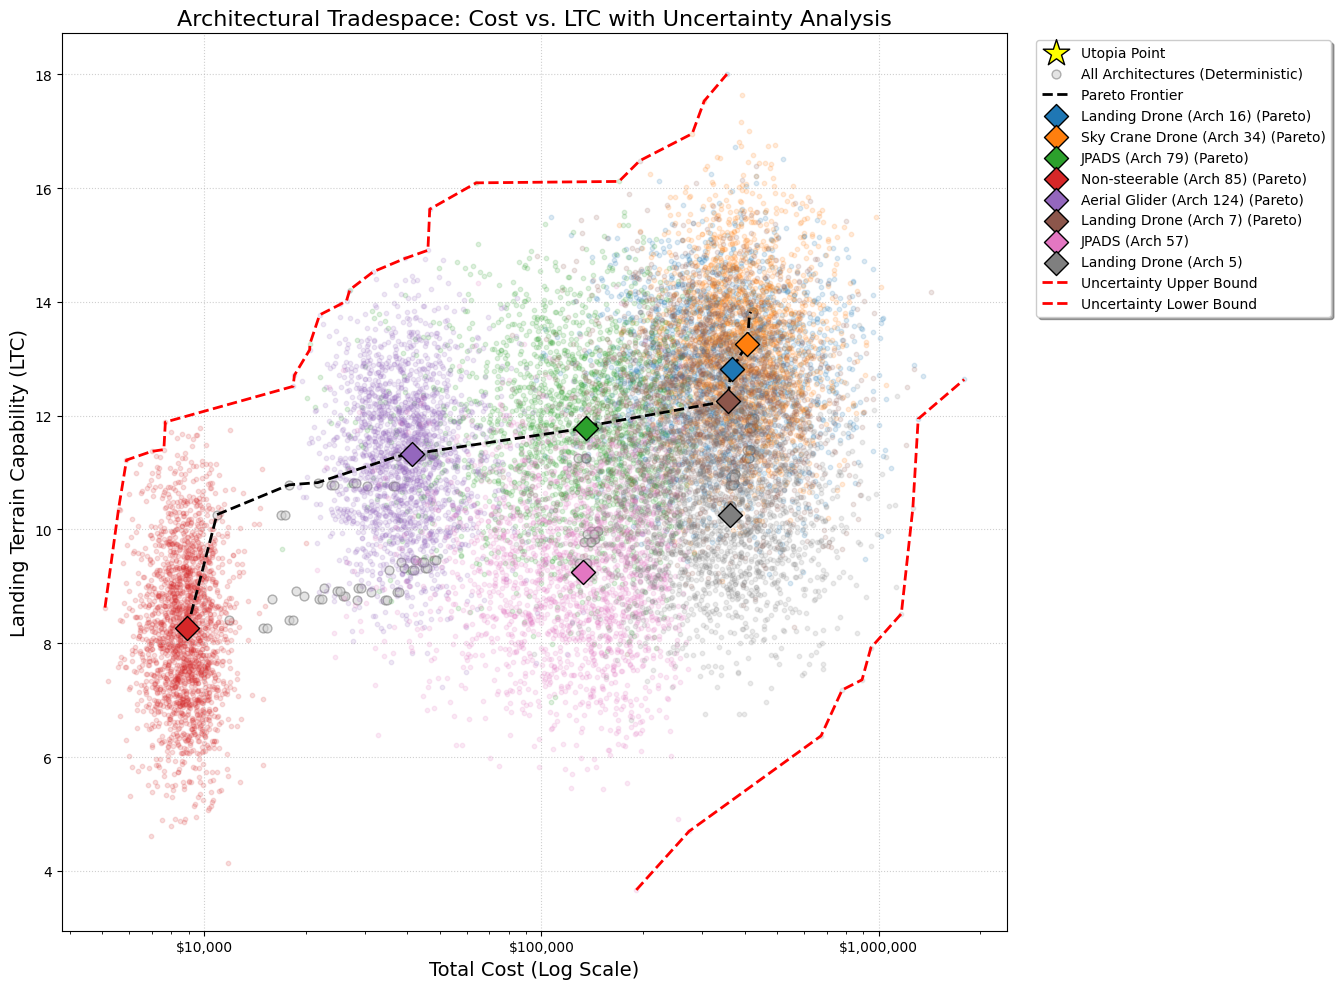

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm

plt.figure(figsize=(14, 10))

# 0. DYNAMIC UTOPIA POINT (Max LTC and Max Cost)
utopia_cost = 0
utopia_ltc = df_simulation_data['Total_LTC'].max()

plt.scatter(utopia_cost, utopia_ltc,
            color='yellow', marker='*', s=400, edgecolors='black',
            zorder=15, label=f'Utopia Point')

# 1. Plot all architectures (Deterministic Baseline)
plt.scatter(df_architectures['Total_Cost'], df_architectures['Total_LTC'],
            c='lightgrey', label='All Architectures (Deterministic)', alpha=0.6, s=40, edgecolors='grey')

# 2. Plot Pareto Frontier
pareto_points = df_architectures[df_architectures['is_pareto']].sort_values('Total_Cost')
plt.plot(pareto_points['Total_Cost'], pareto_points['Total_LTC'],
         c='black', linestyle='--', linewidth=2, label='Pareto Frontier')

# 3. Plot Simulation Results (Uncertainty Clouds) from DataFrame
# Get unique architectures that were simulated
simulated_archs = df_simulation_data['Arch_ID'].unique()
colors = plt.get_cmap('tab10')

for i, arch_id in enumerate(simulated_archs):
    # Modulo 10 prevents index out of bounds error if >10 architectures are simulated
    color = colors(i % 10)

    # Filter simulation data for this specific architecture
    arch_data = df_simulation_data[df_simulation_data['Arch_ID'] == arch_id]

    # Plot the MC samples (Uncertainty Region)
    plt.scatter(arch_data['Total_Cost'], arch_data['Total_LTC'],
                color=color, alpha=0.15, s=10)

    # Plot the deterministic center point
    det_row = df_architectures[df_architectures['Arch_ID'] == arch_id].iloc[0]
    status_label = "(Pareto)" if det_row.get('is_pareto', False) else ""

    # --- UPDATED LOGIC HERE: Get the Deceleration & Guidance name ---
    dec_guidance_name = det_row.get('Deceleration & Guidance', 'Unknown Category')

    plt.scatter(det_row['Total_Cost'], det_row['Total_LTC'],
                color=color, edgecolors='black', s=150, marker='D', zorder=10,
                label=f"{dec_guidance_name} (Arch {arch_id}) {status_label}")

# 4. Plot New Pareto Frontier (Best)
new_pareto_points = df_simulation_data[df_simulation_data['is_new_pareto']].sort_values('Total_Cost')
plt.plot(new_pareto_points['Total_Cost'], new_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Upper Bound')

# 5. Plot Anti-Pareto Frontier (Worst)
anti_pareto_points = df_simulation_data[df_simulation_data['anti_pareto_front']].sort_values('Total_Cost')
plt.plot(anti_pareto_points['Total_Cost'], anti_pareto_points['Total_LTC'],
         c='red', linestyle='--', linewidth=2, label='Uncertainty Lower Bound')

# Formatting the Chart
plt.title('Architectural Tradespace: Cost vs. LTC with Uncertainty Analysis', fontsize=16)
plt.xlabel('Total Cost (Log Scale)', fontsize=14)
plt.ylabel('Landing Terrain Capability (LTC)', fontsize=14)

# --- NEW CODE FOR LOG SCALE ---
plt.xscale('log') # Converts the X-axis to logarithmic

# Formats the ticks to display as "$10,000" instead of "10^4"
formatter = ticker.FuncFormatter(lambda x, pos: f'${int(x):,}')
plt.gca().xaxis.set_major_formatter(formatter)
# ------------------------------

# Place legend outside or adjust loc to prevent it from covering data
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, bbox_to_anchor=(1.35, 1))
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()